# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

## Processing Data
The data is imported directly from Yahoo Finance and Federal Reserve Bank of ST.LOUIS (FRED) using API keys, instead of downloading and uploading the data. This approach is more **memory efficient**.

We are not going to use GDP or Housing Price data as they do not show much variations before each economic recession.

We will divide data exploration into 2 caterogires.
1. Unemployment, Inflation, Interest rate, SP500 (1968-2026)
2. VIX, Gold, Oil Prices (1988-2026)

What is VIX?

The VIX (Cboe Volatility Index), often called the "fear gauge," measures the stock market's expectation of volatility over the next 30 days. It calculates how much investors expect the S&P 500 to swing up or down, acting as a barometer for market risk and investor sentiment. **High VIX numbers mean more fear, while low numbers suggest stability.**

In [2]:
# install libraries from Yahoo Finance Data
!pip install yfinance fredapi

# Exploratory Data Analysis


In [15]:
# Install necessary libraries if not present
# !pip install yfinance fredapi scikit-learn plotly

import yfinance as yf
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import math
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

In [4]:
# Define Global Colors for consistent plotting
COLOR_MAP = {
    'Unemployment': 'blue',
    'Inflation': 'red',
    'Interest': 'green',
    'SP500': 'orange',
    'Oil': 'black',
    'VIX': 'purple',
    'Gold': 'gold'
}

# API key from FRED to extract data
fred = Fred(api_key="65796ccf4eea28ff944ebb1cf7ea91de")

## 1. Data Loading


In [31]:
# Load data from FRED
unemployment = fred.get_series("UNRATE").to_frame(name="Unemployment")
inflation = fred.get_series("FPCPITOTLZGUSA").to_frame(name="Inflation")
interest = fred.get_series("DFF").to_frame(name="Interest")
oil = fred.get_series("DCOILWTICO").to_frame(name="Oil")

# Load data starting from 1968
unemployment = unemployment[unemployment.index >= "1968-01-01"]
inflation = inflation[inflation.index >= "1968-01-01"]
interest = interest[interest.index >= "1968-01-01"]

# Load data from Yahoo Finance
sp500 = yf.download("^GSPC", start="1968-01-01")['Close']
vix = yf.download("^VIX", start="1990-01-01")['Close']
gold = yf.download("^XAU", start="1990-01-01")['Close']


/tmp/ipykernel_34383/494687492.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="1968-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_34383/494687492.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_34383/494687492.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("^XAU", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


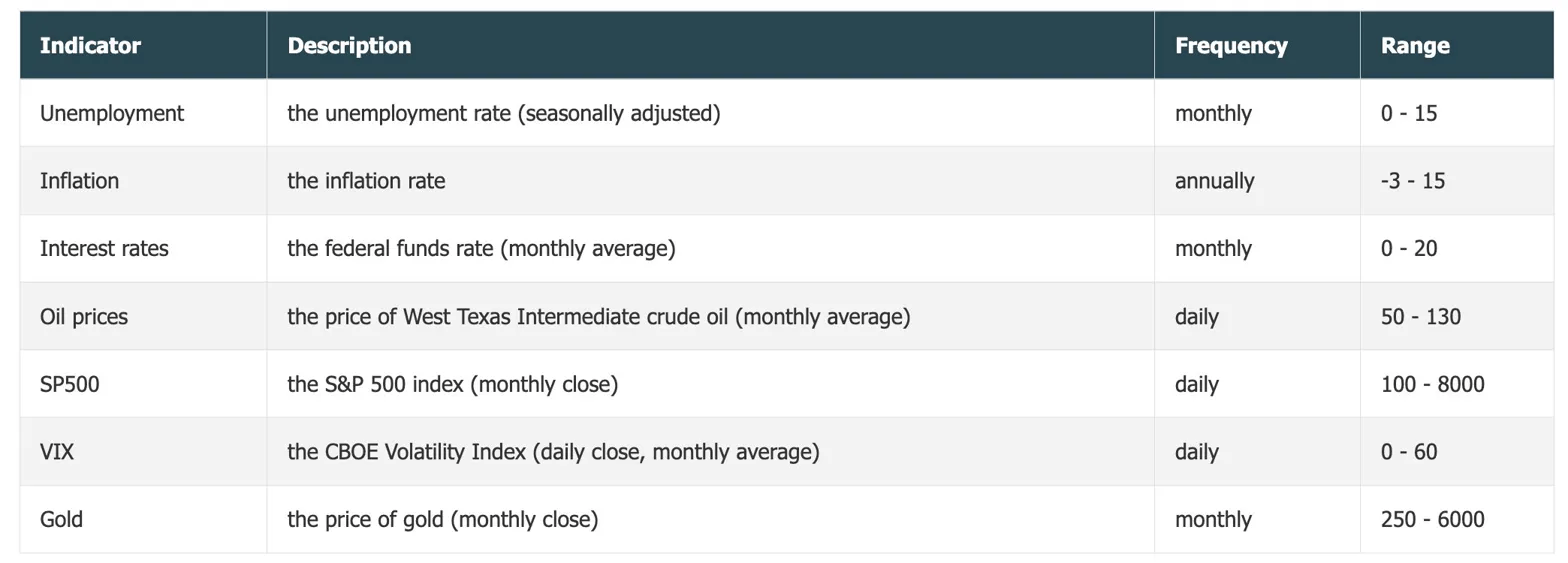

The Data is in different frequency so all of them are converted into monthly frequency for consistency.

As data for VIX, Gold, and Oil are only available starting from around 1988, the dataset was split into two segments: one covering 1968-2026 (Unemployment, Inflation, Interest rates, and S&P 500) and another covering 1990-2026 (VIX, Gold, and Oil).

In [23]:
# Resample all series to monthly frequency
unemployment_monthly = unemployment.resample("ME").last()
inflation_monthly = inflation.resample("ME").last()
inflation_monthly["Inflation"] = inflation_monthly["Inflation"].pct_change(12) * 100
interest_monthly = interest.resample("ME").last()
oil_monthly = oil.resample("ME").last()
sp500_monthly = sp500.resample("ME").last()
vix_monthly = vix.resample("ME").last()
gold_monthly = gold.resample("ME").last()

# Load recession indicator and resample to monthly
recession = fred.get_series("USREC").to_frame(name="Recession")
recession = recession[recession.index >= "1968-01-01"]
recession = recession.resample("ME").last()

# Rename Yahoo Finance DataFrame columns
sp500_monthly.columns = ["SP500"]
vix_monthly.columns = ["VIX"]
gold_monthly.columns = ["Gold"]

/tmp/ipykernel_34383/2200782968.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_monthly["Inflation"] = inflation_monthly["Inflation"].pct_change(12) * 100


In [24]:
# Build df_1968
df_1968 = pd.concat([
    unemployment_monthly,
    inflation_monthly,
    interest_monthly,
    sp500_monthly
], axis=1).merge(recession, left_index=True, right_index=True, how="left")
df_1968 = df_1968[df_1968.index >= "1968-01-01"]

# Build df_1990
df_1990 = pd.concat([
    oil_monthly,
    vix_monthly,
    gold_monthly
], axis=1).merge(recession, left_index=True, right_index=True, how="left")
df_1990 = df_1990.loc["1988":]


## 2. Overall Normalized Trends (Line Graphs)


All the indicators have completely different value ranges (e.g., S&P 500 in thousands vs. Interest rates in small percentages). To plot and compare them effectively, we have applied Min-Max Normalization.

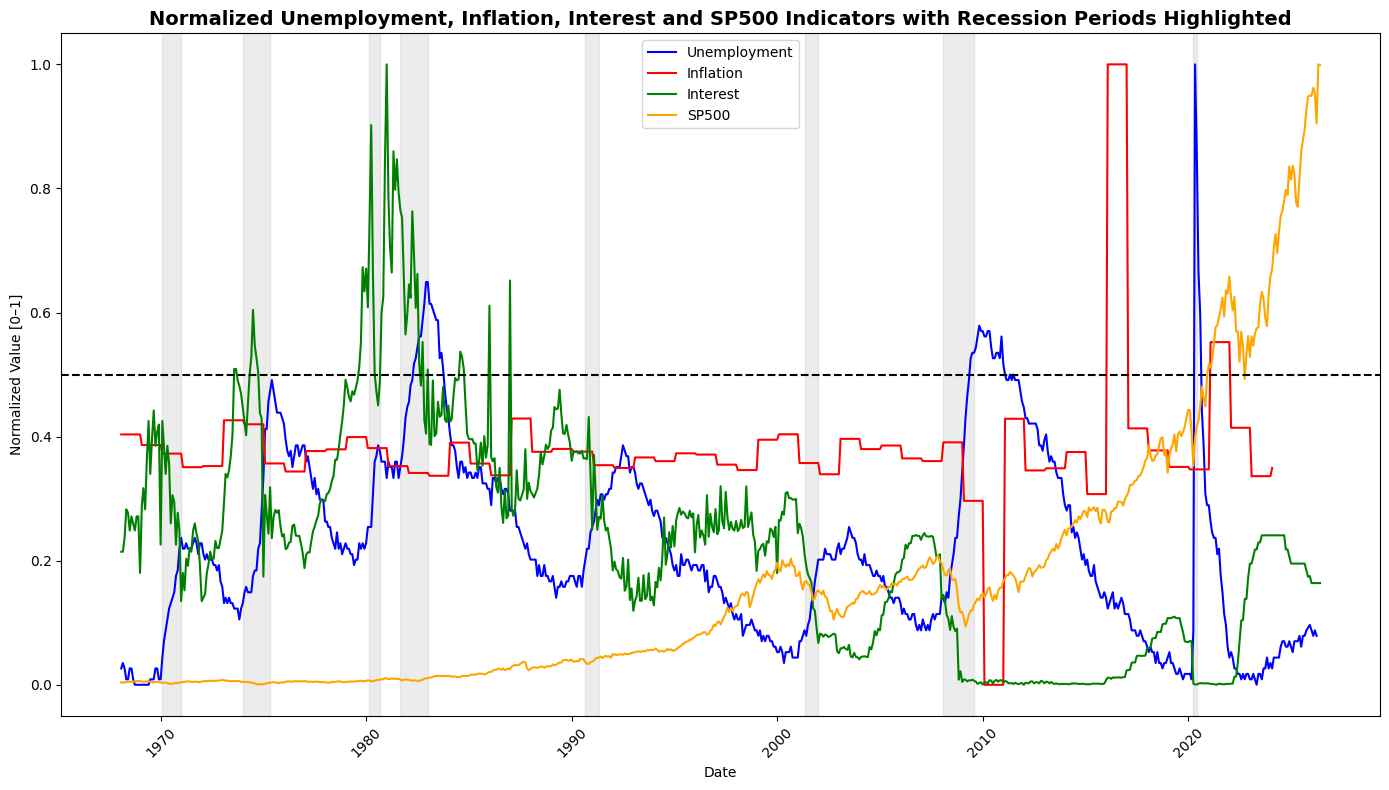

In [25]:
# Normalize df_1968 indicators to [0, 1] — each column independently, ignoring NaNs
scaled_1968 = df_1968.copy()
indicators_1968 = ["Unemployment", "Inflation", "Interest", "SP500"]

for col in indicators_1968:
    col_data = scaled_1968[col].dropna()
    if col_data.empty:
        continue
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        scaled_1968[col] = (scaled_1968[col] - col_min) / (col_max - col_min)

# Full time series line graph for df_1968
plt.figure(figsize=(14, 8))

for col in indicators_1968:
    col_data = scaled_1968[col].dropna()
    if col_data.empty:
        continue
    plt.plot(col_data.index, col_data.values, label=col, color=COLOR_MAP.get(col, 'blue'))

start = None
for date in scaled_1968.index:
    if scaled_1968.loc[date, "Recession"] == 1 and start is None:
        start = date
    elif scaled_1968.loc[date, "Recession"] == 0 and start is not None:
        plt.axvspan(start, date, alpha=0.15, color='gray')
        start = None
if start is not None:
    plt.axvspan(start, scaled_1968.index[-1], alpha=0.15, color='gray')

plt.axhline(0.5, linestyle="--", color='black')
plt.legend(fontsize=10)
plt.title("Normalized Unemployment, Inflation, Interest and SP500 Indicators with Recession Periods Highlighted", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Normalized Value [0–1]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("line_graph_1968.png")
plt.show()

The graph shows how Unemployment, Inflation, Interest rates, and SP500 have changed over time from 1968 to 2026, with shaded areas representing recession periods. As per the graph, Interest rates have been consistently declining since their peak in the early 1980s, while SP500 has been steadily rising over the entire period.

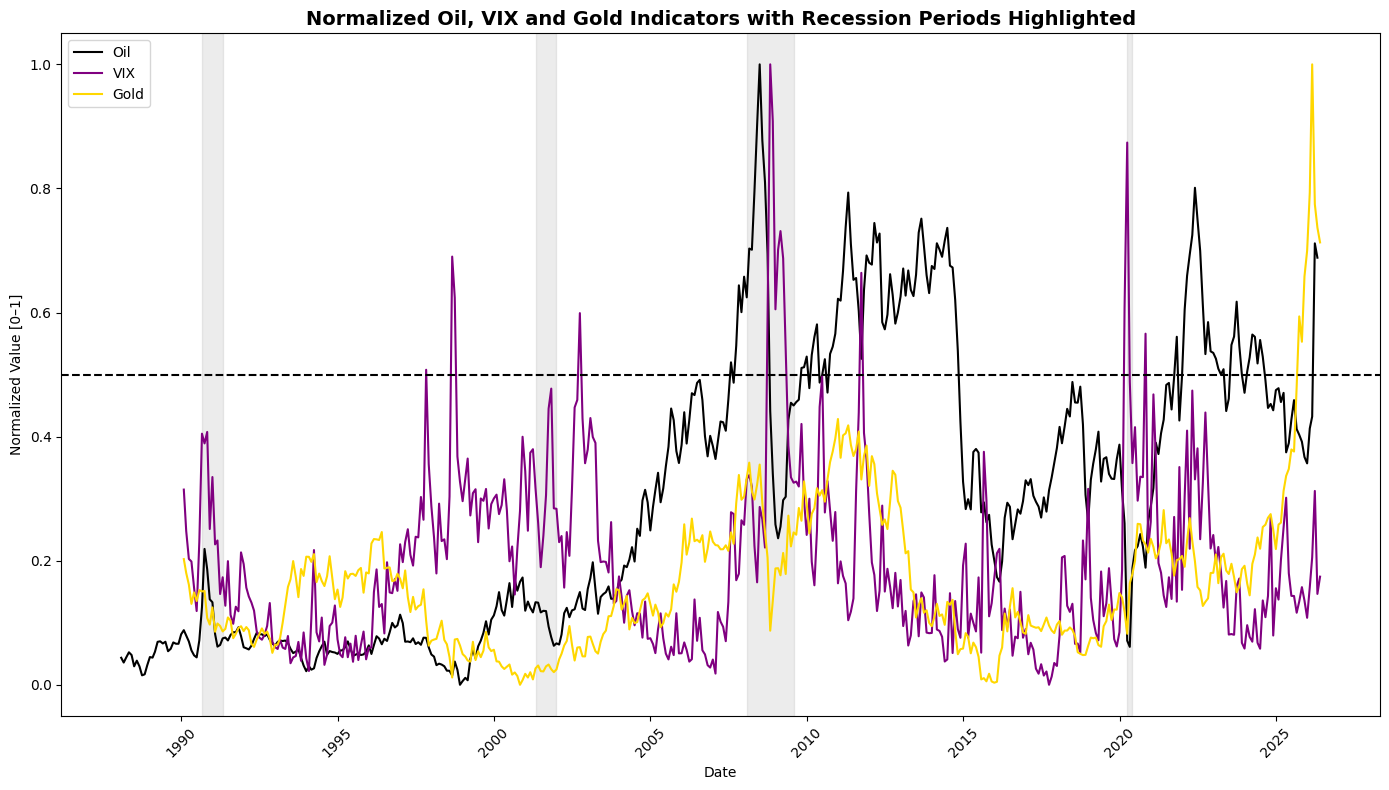

In [26]:
# Normalize df_1990 indicators to [0, 1] — each column independently, ignoring NaNs
scaled_1990 = df_1990.copy()
indicators_1990 = ["Oil", "VIX", "Gold"]

for col in indicators_1990:
    col_data = scaled_1990[col].dropna()
    if col_data.empty:
        continue
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        scaled_1990[col] = (scaled_1990[col] - col_min) / (col_max - col_min)

# Full time series line graph for df_1990
plt.figure(figsize=(14, 8))

for col in indicators_1990:
    col_data = scaled_1990[col].dropna()
    if col_data.empty:
        continue
    plt.plot(col_data.index, col_data.values, label=col, color=COLOR_MAP.get(col, 'black'))

start = None
for date in scaled_1990.index:
    if scaled_1990.loc[date, "Recession"] == 1 and start is None:
        start = date
    elif scaled_1990.loc[date, "Recession"] == 0 and start is not None:
        plt.axvspan(start, date, alpha=0.15, color='gray')
        start = None
if start is not None:
    plt.axvspan(start, scaled_1990.index[-1], alpha=0.15, color='gray')

plt.axhline(0.5, linestyle="--", color='black')
plt.legend(fontsize=10)
plt.title("Normalized Oil, VIX and Gold Indicators with Recession Periods Highlighted", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Normalized Value [0–1]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("line_graph_1990.png")
plt.show()

The graph shows how Oil, VIX, and Gold prices have changed over time from 1985 to 2026, with shaded areas marking recession periods. As per the graph, VIX consistently spikes during every recession, confirming that market volatility rises sharply whenever the economy enters a downturn.

## 3. Zoom-In View (24 months before recessions)


As the overall line graph wasn't able to provide much information, we then plot separate line graphs for all the 8 US economic recession.  

In [27]:
def get_recession_periods(df, recession_col='Recession'):
    periods = []
    start = None
    for date in df.index:
        if df.loc[date, recession_col] == 1 and start is None:
            start = date
        elif df.loc[date, recession_col] == 0 and start is not None:
            periods.append((start, date))
            start = None
    if start is not None:
        periods.append((start, df.index[-1]))
    return periods


def plot_zoom_before_recessions(df, indicator_cols, filename, recession_col='Recession',
                                 months_before=24, months_after=12, title=None, max_recessions=6):
    periods = get_recession_periods(df, recession_col)

    if len(periods) > max_recessions:
        periods = periods[-max_recessions:]

    n_recessions = len(periods)
    cols_grid = 2
    rows_grid = math.ceil(n_recessions / cols_grid)

    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 4 * rows_grid))

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    axes = [axes] if n_recessions == 1 else axes.flatten()

    for i, (start_date, end_date) in enumerate(periods):
        ax = axes[i]

        start_idx = df.index.get_indexer([start_date], method='bfill')[0]
        window_start_idx = max(0, start_idx - months_before)
        window_start_date = df.index[window_start_idx]

        window_end_idx = min(len(df) - 1, start_idx + months_after)
        window_end_date = df.index[window_end_idx]

        plot_df = df.loc[window_start_date:window_end_date, indicator_cols].copy()

        for col in indicator_cols:
            col_data = plot_df[col].dropna()

            # Skip this indicator entirely if no data exists in this window
            if col_data.empty:
                continue

            # Only plot the range where data is actually available
            ax.plot(col_data.index, col_data.values, label=col,
                    color=COLOR_MAP.get(col, 'blue'), linewidth=1.5)

        shade_end = min(end_date, window_end_date)
        ax.axvspan(start_date, shade_end, color='gray', alpha=0.2, label='Recession')
        ax.axvline(start_date, color='red', linestyle='--', linewidth=1.2, label='Recession Start')

        ax.set_ylim(0, 1)
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        ax.set_title(f"Recession starting {start_date.strftime('%Y-%m')}")
        ax.set_ylabel("Normalized (0–1)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

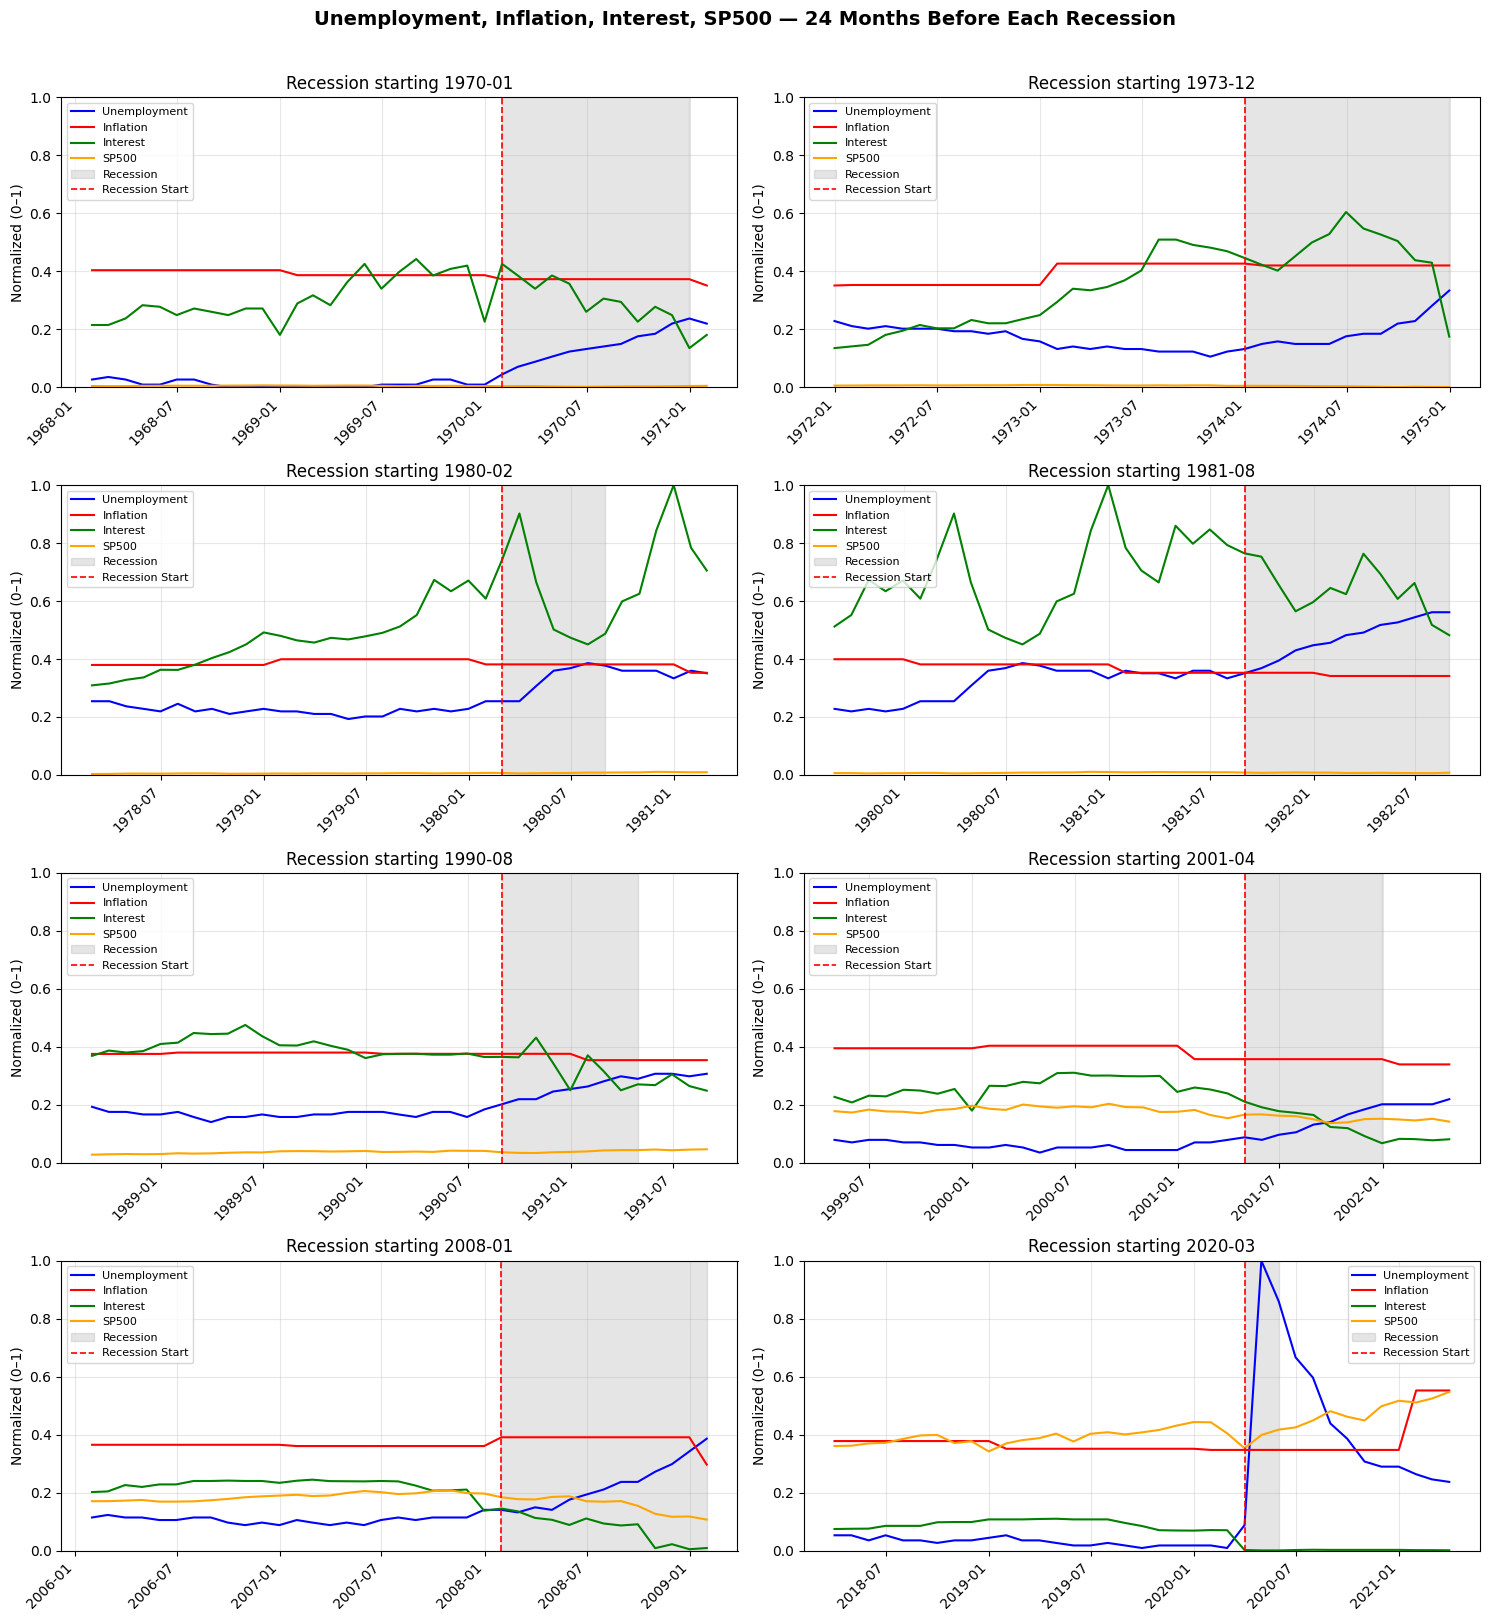

In [29]:
# Close-up view: 24 months before and 12 months into each recession for df_1968
plot_zoom_before_recessions(
    scaled_1968,
    indicator_cols=indicators_1968,
    filename="close_up_view_1968.png",
    months_before=24,
    months_after=12,
    max_recessions=8,
    title="Unemployment, Inflation, Interest, SP500 — 24 Months Before Each Recession"
)

According to the 8 Economic Recession Data


*   Unemployment, Inflation and SP500 don't show much flauation before entering into recessions.
*   On the other hand, interest rate was increasing rapidly before recession, except from 2008 and 2020.



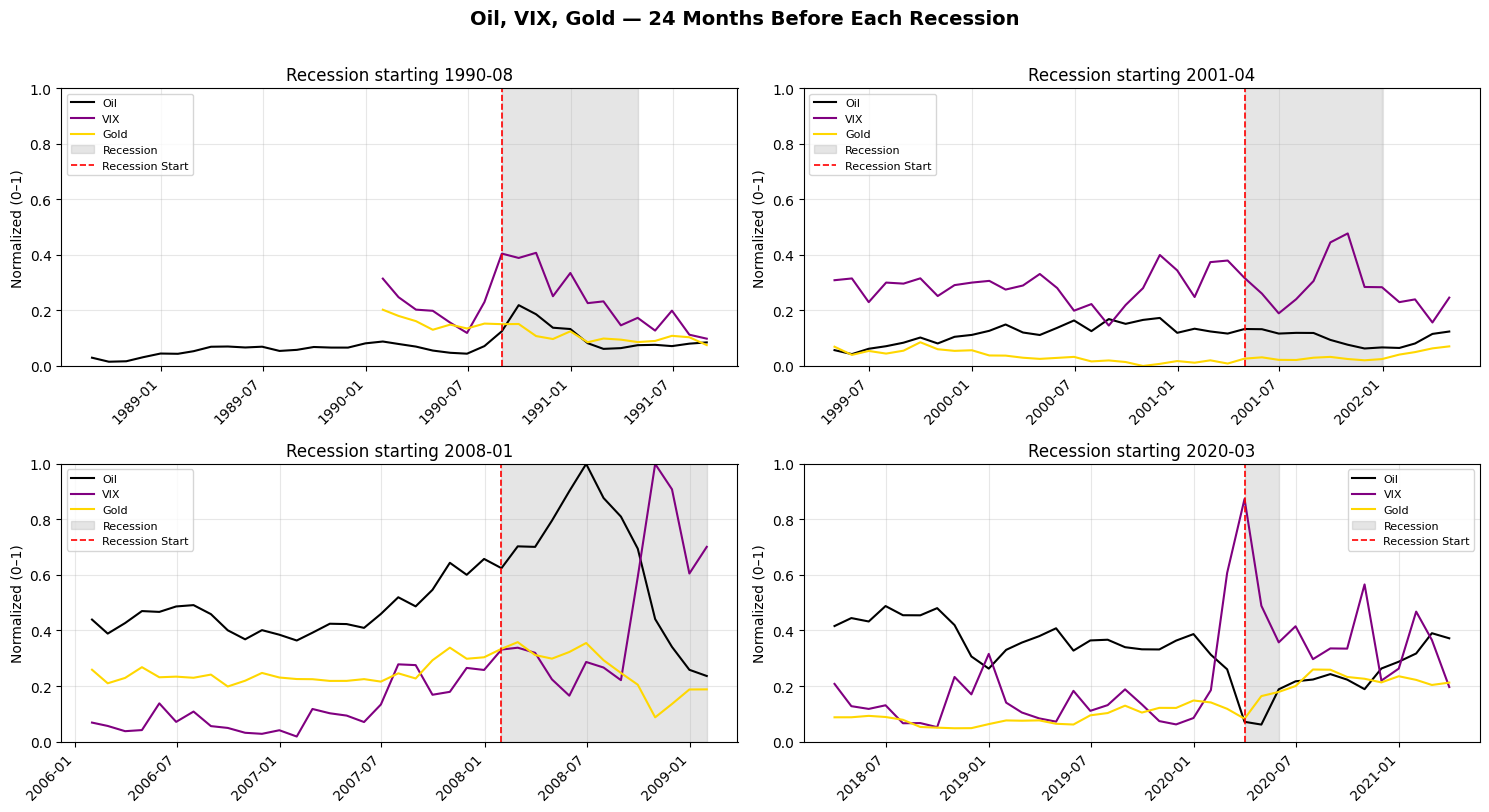

In [30]:
# Close-up view: 24 months before and 12 months into each recession for df_1990
plot_zoom_before_recessions(
    scaled_1990,
    indicator_cols=indicators_1990,
    filename="close_up_view_1990.png",
    months_before=24,
    months_after=12,
    max_recessions=8,
    title="Oil, VIX, Gold — 24 Months Before Each Recession"
)

Oil and VIX data only starts in 1990.

According to the 4 Economic recession Data,


*   Oil Prices increases sharply before 2008 housing crisis
*   VIX increases in all 4 recession
*   Gold prices remain steady with only a small increase in its value before 2008.



## 4. Average Indicator Trajectory Before Recession


After we took a closer look at each economic recession data, we also want to know if there is any pattern averaging across all economic recession comparing to the average value over the period.

To do this, we first standardize the values.

In [ ]:
def indicator_trajectory(df, indicators, recession_col="Recession", months_before=24):
    recession_starts = []
    for i in range(1, len(df)):
        if df[recession_col].iloc[i] == 1 and df[recession_col].iloc[i-1] == 0:
            recession_starts.append(df.index[i])

    trajectories = {col: [] for col in indicators}

    for start_date in recession_starts:
        start_idx = df.index.get_indexer([start_date], method='bfill')[0]
        if start_idx >= months_before:
            window = df.iloc[start_idx - months_before : start_idx + 1]
            for col in indicators:
                trajectories[col].append(window[col].values)

    avg_trajectories = {}
    for col in indicators:
        avg_trajectories[col] = np.mean(trajectories[col], axis=0)

    time_index = np.arange(-months_before, 1)
    traj_df = pd.DataFrame(avg_trajectories, index=time_index)
    return traj_df


In [ ]:
# Trajectory 1968
scaled_1968 = df_1968.loc["1968":].copy()
scaler_1968 = StandardScaler()
indicators_1968 = ["Unemployment", "Inflation", "Interest", "SP500"]
scaled_1968[indicators_1968] = scaler_1968.fit_transform(scaled_1968[indicators_1968])

traj_1968 = indicator_trajectory(
    scaled_1968,
    indicators=indicators_1968,
    months_before=24
)

fig_1968 = go.Figure()

for col in traj_1968.columns:
    fig_1968.add_trace(go.Scatter(
        x=traj_1968.index,
        y=traj_1968[col],
        mode="lines",
        name=col,
        line=dict(color=COLOR_MAP.get(col, 'blue')),
        hovertemplate=f"<b>{col}</b><br>Month: %{{x}}<br>Z-score: %{{y:.2f}}<extra></extra>"
    ))

fig_1968.add_vline(
    x=0,
    line_dash="dash",
    line_color="black",
    annotation_text="Recession Start",
    annotation_position="top right"
)

fig_1968.update_layout(
    title="Average Indicator Trajectory Before Recession — Unemployment, Inflation, Interest, SP500 (1968–2026)",
    xaxis_title="Months Before Recession",
    yaxis_title="Standardized Value (Z-score)",
    hovermode="closest",
    legend_title="Indicator",
    template="plotly_white"
)

fig_1968.write_html("economic_chart_1968.html", include_plotlyjs="cdn", full_html=True)
fig_1968.show()


The graph shows the average Z-score of Unemployment, Inflation, Interest rates, and SP500 across all recorded recessions from 1968 to 2026 in the 24 months leading up to their start, where a positive Z-score means the indicator was above its long-term average and a negative Z-score means it was below that long-term average. As per the graph, Interest rates and Inflation are consistently above their long-term averages throughout the entire 24-month window before a recession, making them the most reliable early warning signals.


**1968 Group (Macro indicators)**
* Unemployment (-18.2%) — Unemployment was nearly 20% below its
historical average before recessions. The labor market looked healthy, giving little warning of an incoming downturn.
* Inflation (+35.6%) — Inflation was running about 36% above normal before recessions. Rising prices were a consistent early warning signal.
* Interest (+47.5%) — Interest rates were almost 50% above their long-run average. The Fed was actively tightening, which historically has preceded recessions.
* SP500 (-22.3%) — Stock prices were about 22% below their historical average before recessions, suggesting markets were already pricing in some weakness.

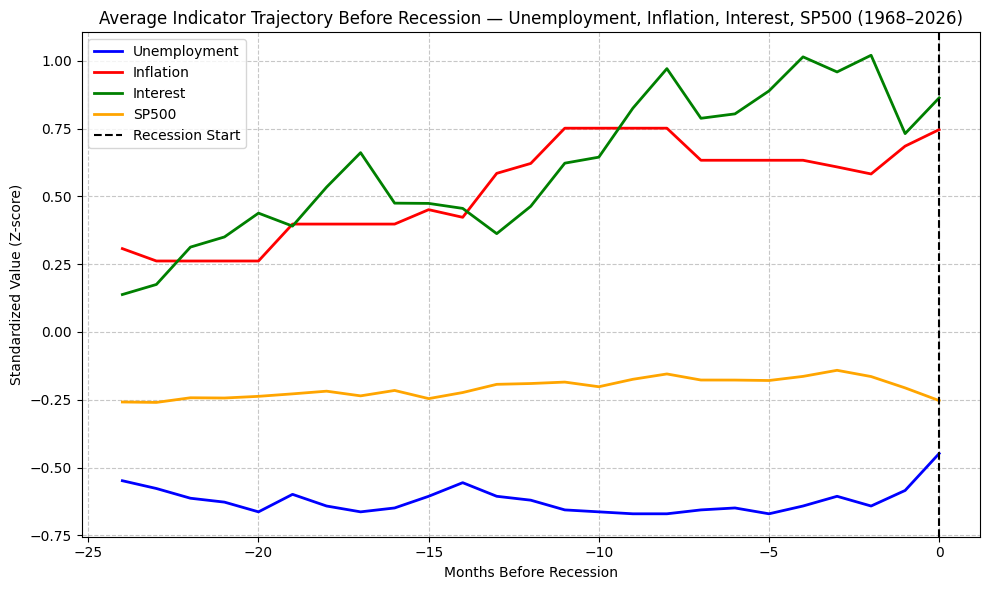

In [ ]:
# Trajectory 1968 (Static Graph)
# plt.figure(figsize=(10, 6))

# for col in traj_1968.columns:
#     plt.plot(traj_1968.index, traj_1968[col], label=col, color=COLOR_MAP.get(col, 'blue'), linewidth=2)

# plt.axvline(x=0, linestyle="--", color="black", label="Recession Start")

# plt.title("Average Indicator Trajectory Before Recession — Unemployment, Inflation, Interest, SP500 (1968–2026)")
# plt.xlabel("Months Before Recession")
# plt.ylabel("Standardized Value (Z-score)")
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)

# plt.tight_layout()
# plt.savefig("average_line_graph_economic_indicator.png")
# plt.show()


In [ ]:
# Trajetory 1990
scaled_1990 = df_1990.copy()
indicators_1990 = ["Oil", "VIX", "Gold"]

for col in indicators_1990:
    col_min = scaled_1990[col].min()
    col_max = scaled_1990[col].max()
    scaled_1990[col] = (scaled_1990[col] - col_min) / (col_max - col_min)

traj_1990 = indicator_trajectory(
    scaled_1990,
    indicators=indicators_1990,
    months_before=24
)

fig_1990 = go.Figure()

for col in traj_1990.columns:
    fig_1990.add_trace(go.Scatter(
        x=traj_1990.index,
        y=traj_1990[col],
        mode="lines",
        name=col,
        line=dict(color=COLOR_MAP.get(col, 'black')),
        hovertemplate=f"<b>{col}</b><br>Month: %{{x}}<br>Normalized: %{{y:.2f}}<extra></extra>"
    ))

fig_1990.add_vline(
    x=0,
    line_dash="dash",
    line_color="black",
    annotation_text="Recession Start",
    annotation_position="top right"
)

fig_1990.update_layout(
    title="Average Indicator Trajectory Before Recession — Oil, VIX, Gold (1990–2026)",
    xaxis_title="Months Before Recession",
    yaxis_title="Normalized Value (0–1)",
    hovermode="closest",
    legend_title="Indicator",
    template="plotly_white"
)

fig_1990.write_html("economic_chart_1990.html", include_plotlyjs="cdn", full_html=True)
fig_1990.show()

The graph shows the average Z-score of Oil, VIX, and Gold across all recorded recessions from 1988 to 2026 in the 24 months leading up to their start, where a positive Z-score means the indicator was above its long-term average and a negative Z-score means it was below that long-term average. As per the graph, VIX spikes dramatically in the final 3 months before a recession starts, driven largely by the extreme market fear seen during the 2008 financial crisis and the 2020 COVID recession.


**1990 Group (Financial/commodity indicators)**
* Oil (+0.7%) — Oil prices were essentially flat vs. their long-run average before recessions — almost no predictive signal here.
* VIX (-3.7%) — Market volatility was actually slightly below average before recessions, meaning markets weren't particularly fearful in advance. This is surprising and suggests VIX spikes during recessions rather than before.
* Gold (-16.7%) — Gold was about 17% below its historical average pre-recession, suggesting investors weren't rushing to safe havens ahead of time.

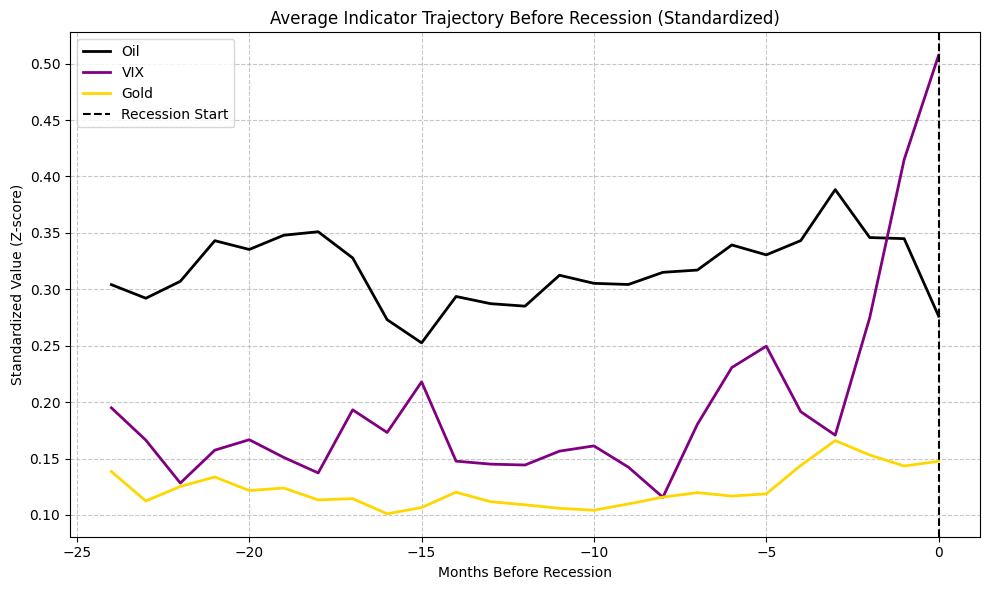

In [ ]:
# Trajectory 1990 (Static Graph)
# plt.figure(figsize=(10, 6))

# for col in traj_1990.columns:
#     plt.plot(traj_1990.index, traj_1990[col], label=col, color=COLOR_MAP.get(col, 'black'), linewidth=2)

# plt.axvline(x=0, linestyle="--", color="black", label="Recession Start")

# plt.title("Average Indicator Trajectory Before Recession (Standardized)")
# plt.xlabel("Months Before Recession")
# plt.ylabel("Standardized Value (Z-score)")
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)

# plt.tight_layout()
# plt.savefig("average_line_graph_financial_indicator.png")
# plt.show()


### Summary table (How to interpret the Average Indicator Trajectory Graphs)

In [ ]:
# ── Summary Table: Average vs Pre-Recession (1968 + 1990 combined) ────────────
def compute_summary(df, indicators):
    rows = []

    recession_starts = []
    for i in range(1, len(df)):
        if df["Recession"].iloc[i] == 1 and df["Recession"].iloc[i-1] == 0:
            recession_starts.append(df.index[i])

    for col in indicators:
        overall_mean = df[col].mean()
        overall_std  = df[col].std()

        pre_recession_vals = []
        for start_date in recession_starts:
            idx = df.index.get_indexer([start_date], method='bfill')[0]
            if idx >= 24:
                window = df.iloc[idx - 24 : idx][col]
                pre_recession_vals.extend(window.values)

        pre_recession_mean = np.mean(pre_recession_vals)
        diff               = pre_recession_mean - overall_mean
        diff_pct           = (diff / overall_mean) * 100

        rows.append({
            "Indicator"                  : col,
            "Overall Mean"               : round(overall_mean, 3),
            "Overall Std"                : round(overall_std, 3),
            "Pre-Recession Mean (24m)"   : round(pre_recession_mean, 3),
            "Difference"                 : round(diff, 3),
            "Difference (%)"             : round(diff_pct, 1),
        })

    return pd.DataFrame(rows).set_index("Indicator")


summary_1968 = compute_summary(df_1968, ["Unemployment", "Inflation", "Interest", "SP500"])
summary_1990 = compute_summary(df_1990, ["Oil", "VIX", "Gold"])

summary_combined = pd.concat([summary_1968, summary_1990])

print("=" * 70)
print("Overall Average vs 24-Month Pre-Recession Average (All Indicators)")
print("=" * 70)
display(summary_combined)

Overall Average vs 24-Month Pre-Recession Average (All Indicators)


,Overall Mean,Overall Std,Pre-Recession Mean (24m),Difference,Difference (%)
Indicator,,,,,
Unemployment,6.031,1.744,4.936,-1.095,-18.2
Inflation,4.064,2.796,5.513,1.449,35.6
Interest,5.095,4.005,7.513,2.418,47.5
SP500,1026.648,1116.438,798.048,-228.600,-22.3
Oil,51.956,29.168,52.335,0.379,0.7
VIX,19.497,7.384,18.769,-0.728,-3.7
Gold,115.069,52.767,95.907,-19.162,-16.7


What does each column mean?
Let's use Unemployment as an example to interpret the table:

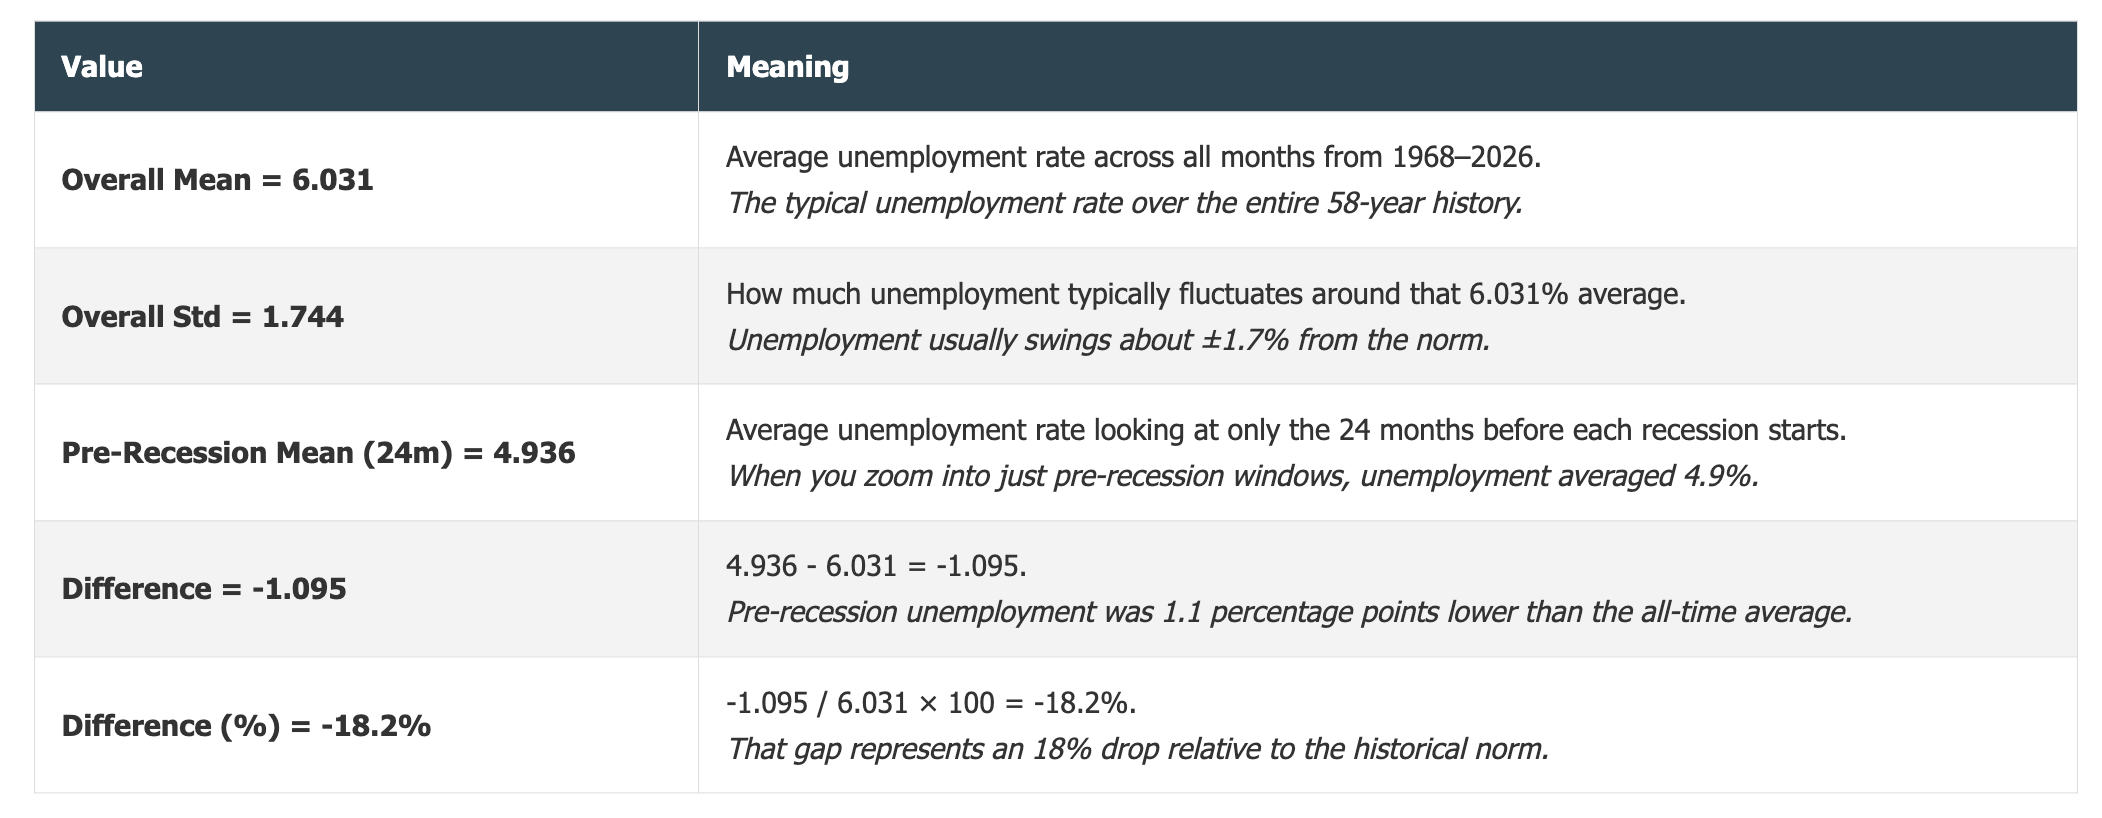

## 5. Individual Indicator Changes Before Recession


In [ ]:
def compute_recession_change(df, indicators, recession_col="Recession", months_before=12):
    """
    Computes the percentage change of economic indicators in the period
    leading up to each recession start.

    For each recession, this function looks back a fixed number of months
    before the recession begins and calculates how much each indicator
    changed from that point to the recession start date.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a DatetimeIndex. Must contain a binary recession
        column and all columns listed in indicators.
    indicators : list of str
        Column names of the economic indicators to measure.
    recession_col : str, optional
        Name of the column indicating recession periods (1 = recession,
        0 = no recession). Default is 'Recession'.
    months_before : int, optional
        How many months before each recession start to use as the
        baseline value. Default is 12.

    Returns
    -------
    pd.DataFrame
        A DataFrame where each row is a recession year and each column
        is an indicator, with values representing the percentage change
        from the baseline month to the recession start.
    """

    # Identify recession start dates: rows where recession switches from 0 to 1
    recession_start = df[(df[recession_col] == 1) & (df[recession_col].shift(1) == 0)].index

    results = {}

    for start in recession_start:

        # Slice all rows up to and including the recession start date
        window = df.loc[:start, indicators]

        # Skip if there is not enough historical data before this recession
        if len(window) > months_before:

            # Baseline value: the row exactly `months_before` months ago
            before = window.iloc[-(months_before + 1)]

            # Value at the moment the recession begins
            start_val = window.iloc[-1]

            # Percentage change from baseline to recession start
            pct_change = (start_val - before) / before * 100

            # Store result keyed by the recession's year
            results[start.year] = pct_change

    # Combine all recession results into a single DataFrame (rows = recession years)
    return pd.DataFrame(results).T

### Heatmap and Bubble plot for 1968_df

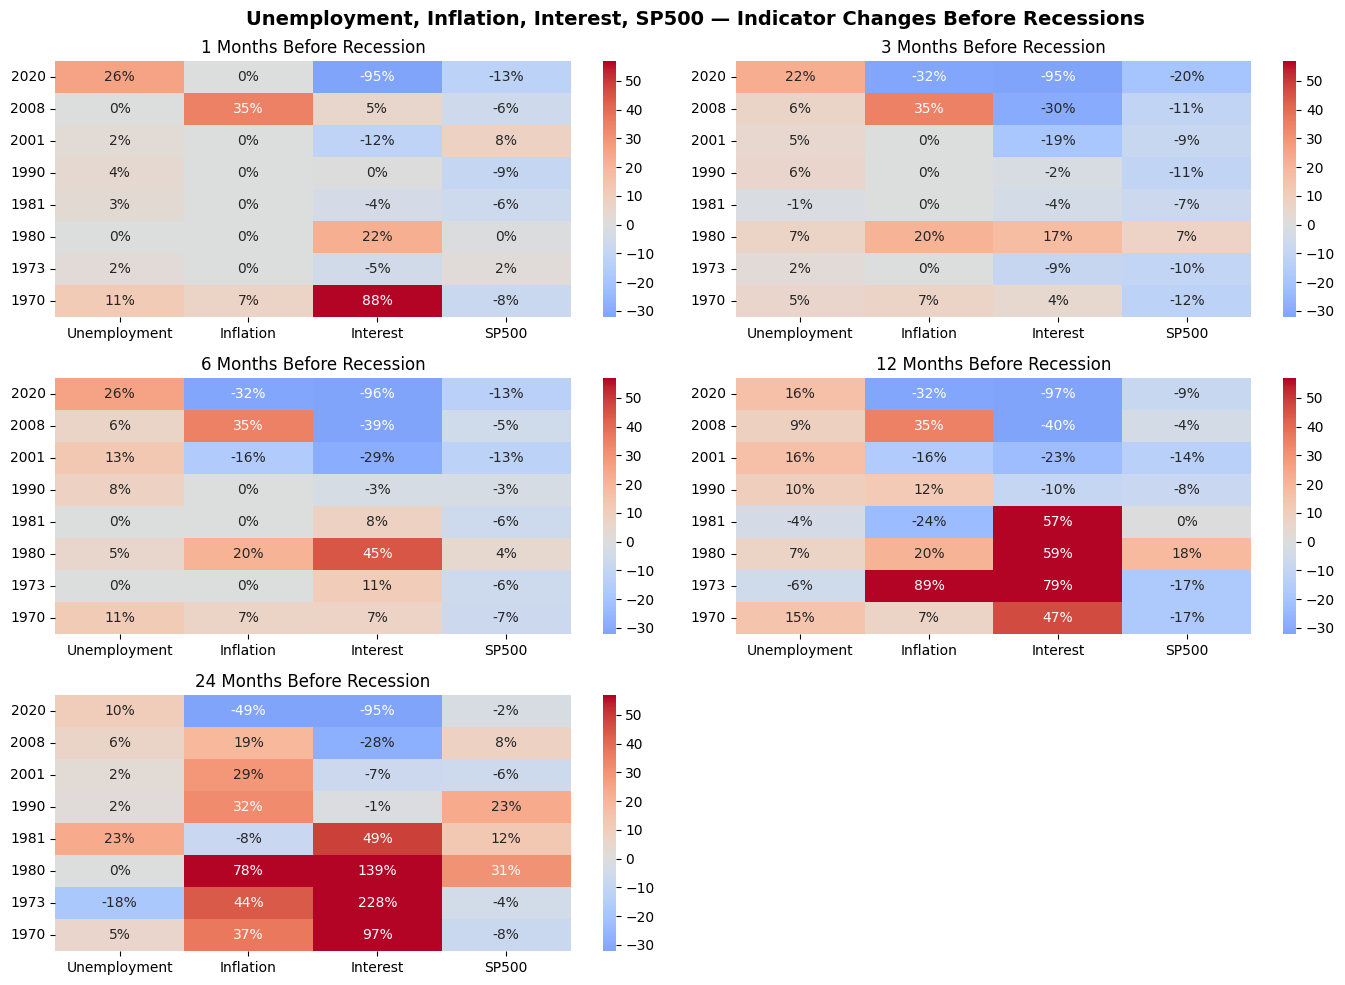

In [ ]:
# Heatmap: df_1968
windows = [1, 3, 6, 12, 24]
indicators_1968 = ["Unemployment", "Inflation", "Interest", "SP500"]

heatmaps_1968 = {}
for w in windows:
    heatmaps_1968[w] = compute_recession_change(df_1968, indicators_1968, months_before=w)

all_vals_1968 = pd.concat(heatmaps_1968.values()).values.flatten()
vmin_1968, vmax_1968 = np.nanpercentile(all_vals_1968, 5), np.nanpercentile(all_vals_1968, 95)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps_1968[w].iloc[::-1]
    annot_data = data.round(0).astype(int).astype(str) + "%"
    sns.heatmap(data, annot=annot_data, fmt="", cmap="coolwarm",
                vmin=vmin_1968, vmax=vmax_1968, center=0, ax=axes[i])
    axes[i].set_title(f"{w} Months Before Recession")

axes[-1].set_visible(False)
plt.suptitle("Unemployment, Inflation, Interest, SP500 — Indicator Changes Before Recessions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("indicator_changes_heatmap_1968.png", bbox_inches='tight')
plt.show()

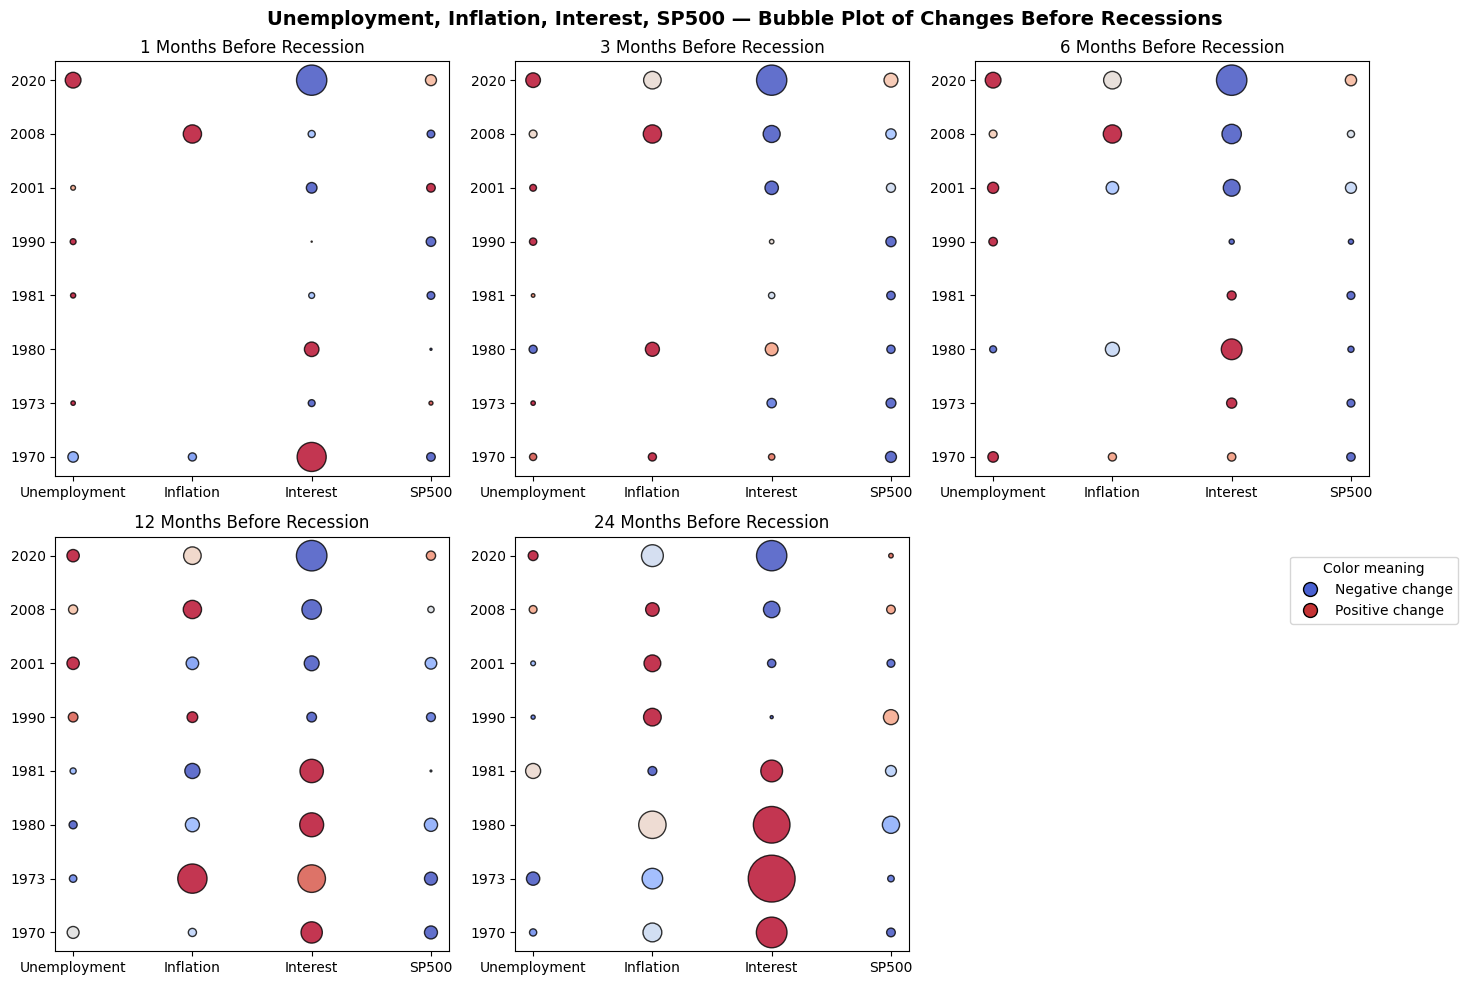

In [ ]:
# Bubble Plot: df_1968
n = len(windows)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, w in enumerate(windows):
    df_change = compute_recession_change(df_1968, indicators=indicators_1968, months_before=w)
    x = np.arange(len(df_change.columns))

    for j, recession in enumerate(df_change.index):
        values = df_change.loc[recession]
        axes[i].scatter(x, [j] * len(x),
                        s=np.abs(values) * 5,
                        c=values, cmap="coolwarm",
                        alpha=0.8, edgecolor="black")

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_change.columns)
    axes[i].set_yticks(range(len(df_change.index)))
    axes[i].set_yticklabels(df_change.index)
    axes[i].set_title(f"{w} Months Before Recession")
    axes[i].margins(0.05)

for k in range(n, len(axes)):
    axes[k].axis("off")

cmap = plt.cm.coolwarm
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Negative change',
           markerfacecolor=cmap(0.05), markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Positive change',
           markerfacecolor=cmap(0.95), markeredgecolor='black', markersize=10)
]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.4),
           frameon=True, title='Color meaning')

plt.suptitle("Unemployment, Inflation, Interest, SP500 — Bubble Plot of Changes Before Recessions", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("indicator_change_bubble_1968.png", bbox_inches='tight')
plt.show()

The heatmaps and bubble plots covering 1968 to 2026 suggests that:

* Unemployment: Typically rises after recession begins, not before. This supports the idea that it is not a strong early warning indicator.
* Inflation: Shows a mixed pattern, with no consistent direction before recessions.
* Interest Rate: Behavior varies across periods because it reflects policy responses rather than direct economic stress.
* S&P 500: Often declines 3 to 6 months before recession. However, 12- and 24-month patterns are less consistent.


These results suggest that recession patterns depend on the underlying cause of the downturn.

### Heat map and Bubble plot for 1990_df

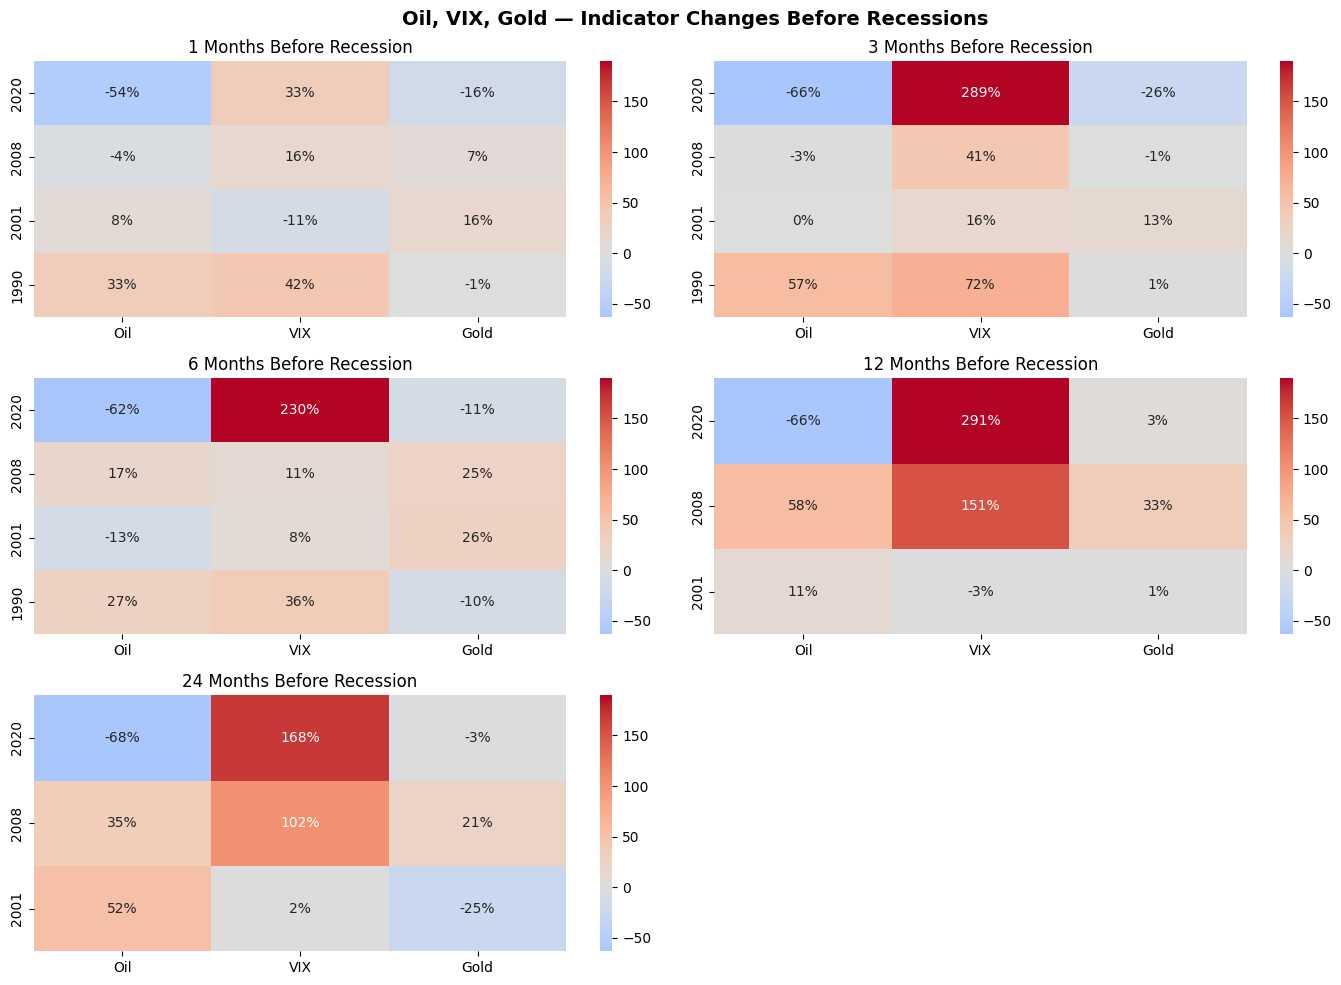

In [ ]:
# Heatmap: df_1990
indicators_1990 = ["Oil", "VIX", "Gold"]

heatmaps_1990 = {}
for w in windows:
    heatmaps_1990[w] = compute_recession_change(df_1990, indicators_1990, months_before=w)

all_vals_1990 = pd.concat(heatmaps_1990.values()).values.flatten()
vmin_1990, vmax_1990 = np.nanpercentile(all_vals_1990, 5), np.nanpercentile(all_vals_1990, 95)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps_1990[w].iloc[::-1]
    annot_data = data.round(0).astype(int).astype(str) + "%"
    sns.heatmap(data, annot=annot_data, fmt="", cmap="coolwarm",
                vmin=vmin_1990, vmax=vmax_1990, center=0, ax=axes[i])
    axes[i].set_title(f"{w} Months Before Recession")

axes[-1].set_visible(False)
plt.suptitle("Oil, VIX, Gold — Indicator Changes Before Recessions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("indicator_changes_heatmap_1990.png", bbox_inches='tight')
plt.show()

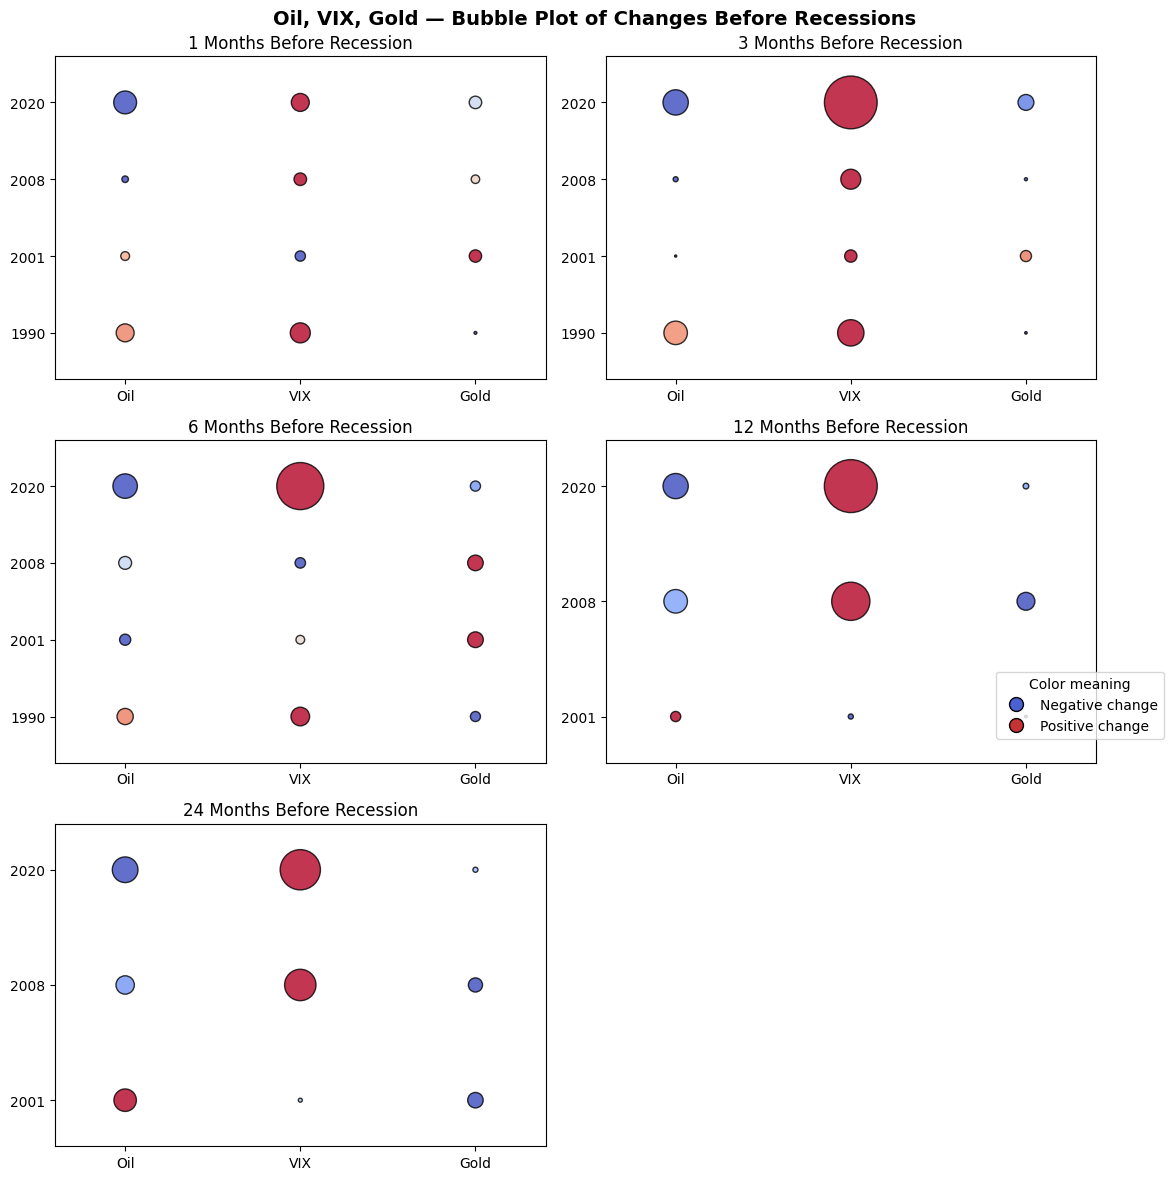

In [ ]:
# Bubble Plot: df_1990
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, w in enumerate(windows):
    df_change = compute_recession_change(df_1990, indicators=indicators_1990, months_before=w)
    x = np.arange(len(df_change.columns))

    for j, recession in enumerate(df_change.index):
        values = df_change.loc[recession]
        axes[i].scatter(x, [j] * len(x),
                        s=np.abs(values) * 5,
                        c=values, cmap="coolwarm",
                        alpha=0.8, edgecolor="black")

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_change.columns)
    axes[i].set_yticks(range(len(df_change.index)))
    axes[i].set_yticklabels(df_change.index)
    axes[i].set_title(f"{w} Months Before Recession")
    axes[i].margins(0.2)

for k in range(n, len(axes)):
    axes[k].axis("off")

cmap = plt.cm.coolwarm
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Negative change',
           markerfacecolor=cmap(0.05), markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Positive change',
           markerfacecolor=cmap(0.95), markeredgecolor='black', markersize=10)
]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.4),
           frameon=True, title='Color meaning')

plt.suptitle("Oil, VIX, Gold — Bubble Plot of Changes Before Recessions", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("indicator_change_bubble_1990.png", bbox_inches='tight')
plt.show()

The heatmaps and bubble plots covering 1990 to 2026 suggests that:

* S&P 500: Gradually decreases before most recessions.
VIX: Spikes sharply as recession approaches, especially in the short term.
* Gold and Oil prices: Does not show a consistent pattern across recessions.

These findings indicate that market-based indicators may provide earlier signals than macroeconomic variables.

## 6. Correlation between Indicators


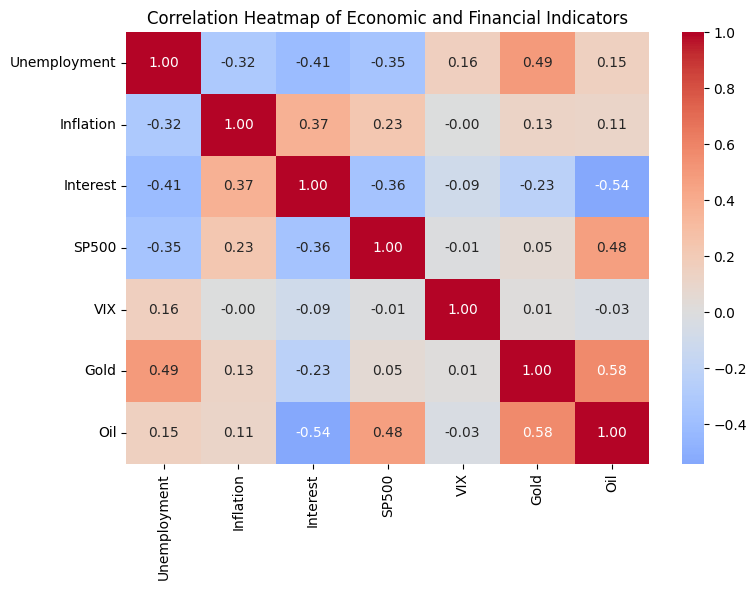

In [ ]:
# Correlation Map for All Indicators
combined_df = pd.concat([
    df_1968[["Unemployment", "Inflation", "Interest", "SP500"]],
    df_1990[["VIX", "Gold", "Oil"]]
], axis=1).dropna()

combined_corr = combined_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(combined_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Economic and Financial Indicators")
plt.tight_layout()
plt.savefig("correlation-of-financial-economic-indicator.png")
plt.show()


Based on the heatmap, we observe that inflation and interest rates have a strong positive correlation (0.69). This is because central banks raise interest rates to control rising inflation. When inflation increases, the Federal Reserve typically increases rates to reduce spending and slow price growth.

The S&P 500 has a negative correlation with interest rates (-0.46). Higher interest rates increase borrowing costs for companies and reduce future earnings expectations, which can lower stock prices.

The S&P 500 also has a negative correlation with unemployment (-0.37). When unemployment rises, consumer spending and company profits often decline, which negatively affects stock performance.

Gold shows a moderate positive correlation with the S&P 500 (0.41), suggesting that in some periods both may rise due to broader economic growth or liquidity conditions.

Overall, while the correlations are moderate rather than strong, they reflect logical economic relationships between monetary policy, economic conditions, and financial markets.